# Лекция-практика: Image Formation
В этом ноутбуке мы пройдем путь:
1. Геометрия и гомогенные координаты
2. 2D-преобразования
3. 3D-преобразования
4. Проекция 3D → 2D
5. Фокусное расстояние
6. Использование OpenCV для проекций

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Геометрия и гомогенные координаты

In [2]:
point = np.array([2, 3, 1])  # (x, y, 1)
print("Гомогенная точка:", point)

Гомогенная точка: [2 3 1]


## 2D-преобразования

[[0 0 1]
 [1 0 1]
 [1 1 1]
 [0 1 1]]


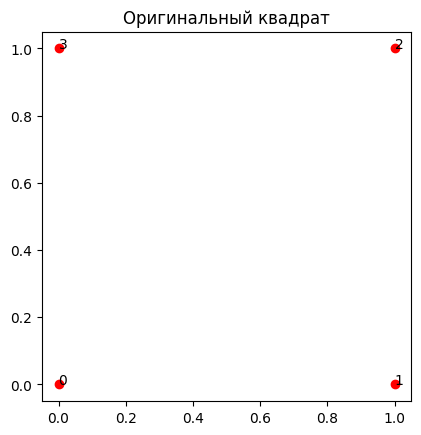

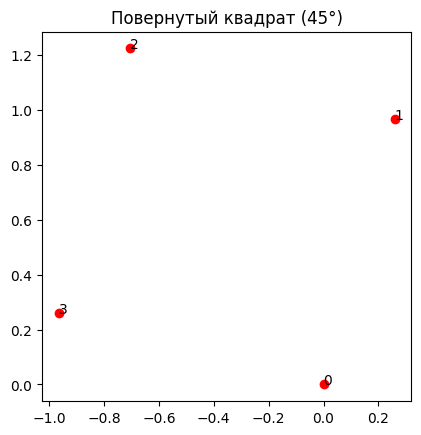

In [6]:
def plot_points(pts, title=""):
    plt.figure()
    plt.scatter(pts[:,0], pts[:,1], c="red")
    for i, (x, y,z) in enumerate(pts):
        plt.text(x, y, str(i))
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.show()

square = np.array([
    [0,0,1],
    [1,0,1],
    [1,1,1],
    [0,1,1]
])

theta = np.deg2rad(75)
R = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
])

rotated = square @ R.T
print(square)
plot_points(square, "Оригинальный квадрат")
plot_points(rotated, "Повернутый квадрат (45°)")

## 3D-преобразования

In [9]:
cube = np.array([
    [-1,-1, 1, 1],
    [ 1,-1, 1, 1],
    [ 1, 1, 1, 1],
    [-1, 1, 1, 1],
    [-1,-1,-1, 1],
    [ 1,-1,-1, 1],
    [ 1, 1,-1, 1],
    [-1, 1,-1, 1],
])

theta = np.deg2rad(30)
Ry = np.array([
    [ np.cos(theta), 0, np.sin(theta), 0],
    [ 0,             1, 0,             0],
    [-np.sin(theta), 0, np.cos(theta), 0],
    [ 0,             0, 0,             1]
])

cube_rot = cube @ Ry.T
print("Пример поворота первой точки:", cube[0], "→", cube_rot[0])

Пример поворота первой точки: [-1 -1  1  1] → [-0.3660254 -1.         1.3660254  1.       ]


## Проекция 3D → 2D (перспектива)

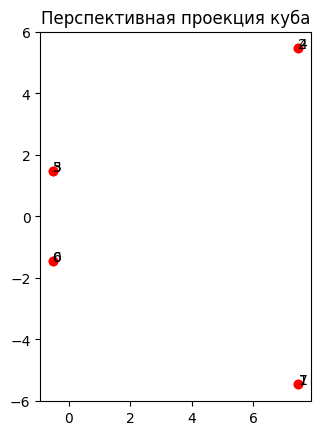

In [11]:
def plot_points(pts, title=""):
    plt.figure()
    plt.scatter(pts[:,0], pts[:,1], c="red")
    for i, (x, y) in enumerate(pts):
        plt.text(x, y, str(i))
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.show()
    
def project_perspective(points, f=1.5):
    projected = []
    for x,y,z,_ in points:
        projected.append([f*x/z, f*y/z])
    return np.array(projected)

proj = project_perspective(cube_rot, f=2.0)
plot_points(proj, "Перспективная проекция куба")

## Влияние фокусного расстояния

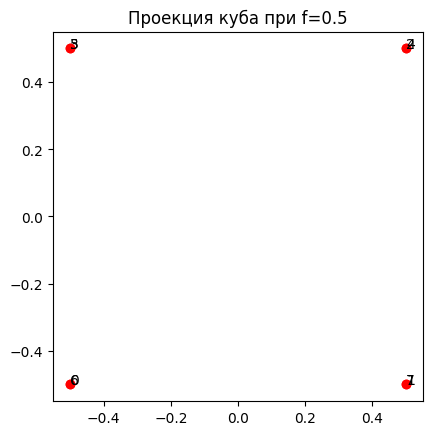

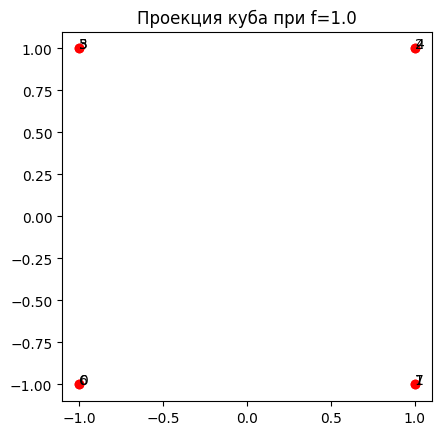

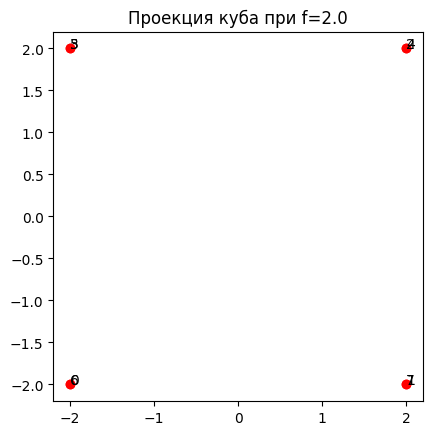

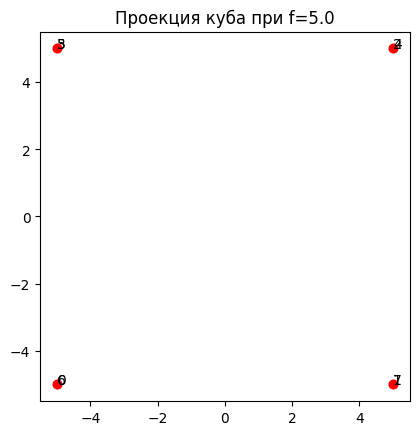

In [12]:
for f in [0.5, 1.0, 2.0, 5.0]:
    proj = project_perspective(cube, f=f)
    plot_points(proj, f"Проекция куба при f={f}")

## OpenCV: cv2.projectPoints

In [13]:
fx, fy = 800, 800
cx, cy = 320, 240
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]], dtype=np.float32)

points_3D = np.array([[0,0,5],[1,1,5],[2,2,10]], dtype=np.float32)
rvec = np.zeros(3)
tvec = np.zeros(3)

points_2D, _ = cv2.projectPoints(points_3D, rvec, tvec, K, None)
print("3D → 2D:", points_2D.reshape(-1,2))

3D → 2D: [[320. 240.]
 [480. 400.]
 [480. 400.]]


## Итог

In [ ]:
print("Сегодня мы увидели:")
print("- 2D и 3D преобразования")
print("- перспективную проекцию")
print("- влияние фокусного расстояния")
print("- работу функции projectPoints из OpenCV")